In [10]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import ipywidgets as widgets
from pybaseball import statcast
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Settings: Summer 2025 (The "Sweet Spot" for data volume)
start_date = "2025-06-01"
end_date = "2025-08-31"
filename = "summer_2025.csv"

def get_data():
    if os.path.exists(filename):
        df = pd.read_csv(filename)
    else:
        df = statcast(start_dt=start_date, end_dt=end_date)
        df.to_csv(filename, index=False)
    return df

raw_df = get_data()
print(f"Raw data loaded: {len(raw_df)} rows")

Reading data from local file...
Raw data loaded: 347419 rows


In [12]:
def prep_data(df):
    # Filter for only called balls and strikes
    df = df.copy()
    valid_calls = ['ball', 'called_strike', 'blocked_ball']
    df = df[df['description'].isin(valid_calls)]
    
    cols = ['plate_x', 'plate_z', 'sz_top', 'sz_bot', 'release_speed']
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        
    # Drop pitches where the tracking failed
    df = df.dropna(subset=['plate_x', 'plate_z'])
    
    df['sz_top'] = df['sz_top'].fillna(3.5)
    df['sz_bot'] = df['sz_bot'].fillna(1.5)
    
    # Create the "Ground Truth" (Rulebook Strike)
    # 0.83 ft is approx 17 inches (plate) + ball radius
    df['is_strike'] = (
        (df['plate_x'].abs() <= 0.83) &
        (df['plate_z'] >= df['sz_bot']) & 
        (df['plate_z'] <= df['sz_top'])
    ).astype(int)
    
    # Convert umpire calls to 0 or 1
    df['umpire_call'] = df['description'].apply(lambda x: 1 if 'called_strike' in x else 0)
    
    # Check if the umpire got it right
    df['correct_call'] = (df['umpire_call'] == df['is_strike'])
    
    # Fix the Umpire Name column
    if 'umpire' not in df.columns:
        if 'umpire_name' in df.columns:
            df = df.rename(columns={'umpire_name': 'umpire'})
        elif 'home_plate_umpire' in df.columns:
            df = df.rename(columns={'home_plate_umpire': 'umpire'})
        else:
            df['umpire'] = 'Unknown'

    df = df.reset_index(drop=True)
    
    return df

df = prep_data(raw_df)
print(f"Cleaned data ready for modeling. Total pitches: {len(df)}")

Cleaned data ready for modeling. Total pitches: 178813


In [14]:
features = ['plate_x', 'plate_z', 'release_speed', 'p_throws', 'stand']
X = df[features].copy()
y = df['is_strike']

# Convert 'L'/'R' to numbers
X = pd.get_dummies(X, columns=['p_throws', 'stand'], drop_first=True)

# Split into train and test (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

preds = model.predict(X_test)
model_acc = accuracy_score(y_test, preds)

human_calls = df.loc[X_test.index, 'umpire_call']
human_acc = accuracy_score(y_test, human_calls)

print("\nResults:")
print(f"Robot Accuracy: {model_acc:.2%}")
print(f"Human Accuracy: {human_acc:.2%}")
print(f"Difference: {(model_acc - human_acc)*100:.2f}% improvement")


Results:
Robot Accuracy: 96.56%
Human Accuracy: 92.88%
Difference: 3.67% improvement


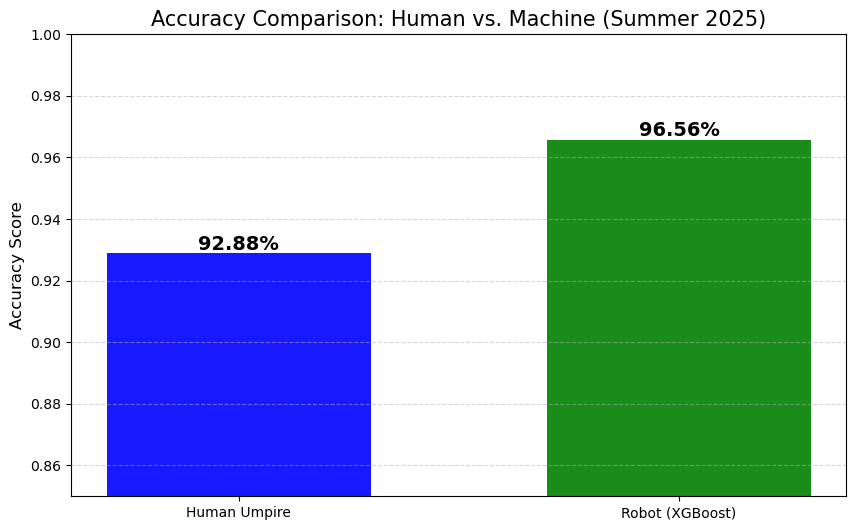

In [16]:
# VISUALIZATION 1: ACCURACY COMPARISON

robot_accuracy = model_acc
human_accuracy = human_acc

groups = ['Human Umpire', 'Robot (XGBoost)']
scores = [human_accuracy, robot_accuracy]
bar_colors = ['blue', 'green']


plt.figure(figsize=(10, 6))
bars = plt.bar(groups, scores, color=bar_colors, alpha=0.9, width=0.6)

# 3. Add Labels and Title
plt.title('Accuracy Comparison: Human vs. Machine (Summer 2025)', fontsize=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.85, 1.0)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height,                            
        f'{height:.2%}',                  
        ha='center', va='bottom', fontsize=14, fontweight='bold'
    )


plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.show()

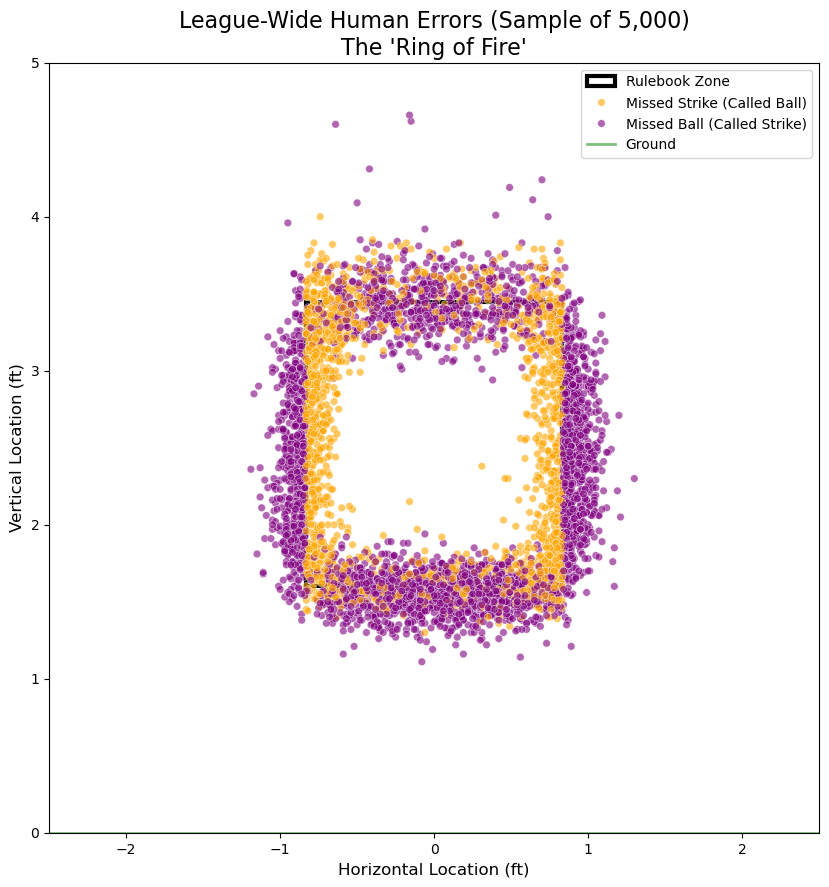

In [18]:
# VISUALIZATION 2: LEAGUE-WIDE ERRORS


def plot_league_errors():
    plt.figure(figsize=(10, 10))
    
    # 1. Draw the Rulebook Strike Zone
    avg_top = df['sz_top'].mean()
    avg_bot = df['sz_bot'].mean()
    
    if pd.isna(avg_top): avg_top = 3.5
    if pd.isna(avg_bot): avg_bot = 1.5

    rect = patches.Rectangle(
        (-0.83, avg_bot), 1.66, avg_top - avg_bot, 
        linewidth=3, edgecolor='black', facecolor='none', label='Rulebook Zone'
    )
    plt.gca().add_patch(rect)
    
    # Filter for ERRORS only
    errors = df[df['correct_call'] == False].copy()
    
    # Random sample of 5,000 errors
    if len(errors) > 5000:
        errors = errors.sample(5000, random_state=42)
        

    errors['label'] = np.where(errors['is_strike'] == 1, 
                               'Missed Strike (Called Ball)', 
                               'Missed Ball (Called Strike)')
    

    colors = {'Missed Strike (Called Ball)': 'orange', 
              'Missed Ball (Called Strike)': 'purple'}
    
    sns.scatterplot(
        data=errors, x='plate_x', y='plate_z', 
        hue='label', palette=colors, s=30, alpha=0.6
    )
    

    plt.title(f"League-Wide Human Errors (Sample of 5,000)\nThe 'Ring of Fire'", fontsize=16)
    plt.xlim(-2.5, 2.5)
    plt.ylim(0, 5)
    plt.axhline(0, color='green', linewidth=2, alpha=0.5, label='Ground') 
    plt.gca().set_aspect('equal') # IMPORTANT: Makes the box square, not stretched
    plt.legend(loc='upper right')
    plt.xlabel("Horizontal Location (ft)", fontsize=12)
    plt.ylabel("Vertical Location (ft)", fontsize=12)
    
    plt.show()

# Run the function
plot_league_errors()

In [ ]:
# VISUALIZATION 3: DISTRIBUTION OF ERROR (HISTOGRAM)

def plot_umpire_distribution():
    ump_stats = df.groupby('umpire').agg(
        total_calls=('umpire_call', 'count'),
        incorrect_calls=('correct_call', lambda x: (~x).sum())
    ).reset_index()


    ump_stats = ump_stats[ump_stats['total_calls'] > 100].copy()
    

    ump_stats['error_rate'] = (ump_stats['incorrect_calls'] / ump_stats['total_calls']) * 100
    
    best_ump = ump_stats.loc[ump_stats['error_rate'].idxmin()]
    worst_ump = ump_stats.loc[ump_stats['error_rate'].idxmax()]
    avg_error = ump_stats['error_rate'].mean()

    plt.figure(figsize=(10, 6))
    
    sns.histplot(data=ump_stats, x='error_rate', bins=15, kde=True, color='skyblue', edgecolor='black')

    plt.axvline(avg_error, color='red', linestyle='--', linewidth=2, label=f'League Avg ({avg_error:.1f}%)')
    
    plt.text(best_ump['error_rate'], 1, 
             f"Best: {best_ump['umpire']}\n({best_ump['error_rate']:.1f}%)", 
             horizontalalignment='center', color='green', fontweight='bold')

    plt.text(worst_ump['error_rate'], 1, 
             f"Worst: {worst_ump['umpire']}\n({worst_ump['error_rate']:.1f}%)", 
             horizontalalignment='center', color='darkred', fontweight='bold')

    plt.title('The "Bell Curve" of Human Error (Summer 2025)', fontsize=15)
    plt.xlabel('Missed Call Percentage', fontsize=12)
    plt.ylabel('Number of Umpires', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

In [20]:
import requests
import time
from tqdm.notebook import tqdm

def fetch_umpire_names(df):
    
    unique_games = df['game_pk'].unique()
    print(f"Found {len(unique_games)} unique games to check.")
    
    game_umpire_map = {}
    
    for game_pk in tqdm(unique_games):
        url = f"https://statsapi.mlb.com/api/v1/game/{game_pk}/boxscore"
        try:
            resp = requests.get(url).json()
            officials = resp.get('info', [])
            
            found = False
            if 'officials' in resp:
                for official in resp['officials']:
                    if official['officialType'] == 'Home Plate':
                        game_umpire_map[game_pk] = official['official']['fullName']
                        found = True
                        break
            
            if not found:
                game_umpire_map[game_pk] = "Unknown"
                
        except Exception as e:
            game_umpire_map[game_pk] = "Error"
            
        # Sleep briefly for API safety
        time.sleep(0.05)
        
    # 3. Map the names back to your main DataFrame
    df['umpire'] = df['game_pk'].map(game_umpire_map)
    
    return df

if df['umpire'].nunique() <= 1:
    df = fetch_umpire_names(df)
    print("Umpire names restored! You can now run the Dashboard.")
else:
    print("You already have umpire names! No need to scrape.")

Found 1187 unique games to check.


  0%|          | 0/1187 [00:00<?, ?it/s]

Umpire names restored! You can now run the Dashboard.


In [24]:
# FINAL PART: DYNAMIC HEIGHT DASHBOARD

# 1. Prepare Umpire List
ump_counts = df['umpire'].value_counts()
ump_list = ump_counts[ump_counts >= 100].index.sort_values().tolist()

def plot_dynamic_dashboard(umpire, batter_size, view_mode):
    if not umpire:
        print("Please select an umpire.")
        return

    # 1. Filter by Umpire
    sub = df[df['umpire'] == umpire].copy()
    
    #    - Short: Zone Top < 3.35 ft
    #    - Average: 3.35 ft <= Zone Top <= 3.65 ft
    #    - Tall: Zone Top > 3.65 ft
    if batter_size == "Short Batters (< 5'10 approx)":
        sub = sub[sub['sz_top'] < 3.35]
    elif batter_size == "Tall Batters (> 6'2 approx)":
        sub = sub[sub['sz_top'] > 3.65]
    elif batter_size == "Average Height Batters":
        sub = sub[(sub['sz_top'] >= 3.35) & (sub['sz_top'] <= 3.65)]
    # "All Batters" does no filtering
    
    if len(sub) == 0:
        print(f"No data found for {umpire} with {batter_size}.")
        return

    top = sub['sz_top'].mean()
    bot = sub['sz_bot'].mean()
    
    # Setup Plot
    plt.figure(figsize=(9, 9))
    
    rect = patches.Rectangle(
        (-0.83, bot), 1.66, top-bot, 
        linewidth=2, edgecolor='black', facecolor='none', label=f'Zone ({batter_size})'
    )
    plt.gca().add_patch(rect)
    
    # 4. Filter for Errors vs All
    if view_mode == 'Show Missed Calls (Errors Only)':
        data = sub[sub['correct_call'] == False].copy()
        data['label'] = np.where(data['is_strike'] == 1, 'Missed Strike', 'Missed Ball')
        palette = {'Missed Strike': 'orange', 'Missed Ball': 'purple'}
    else:
        data = sub.copy()
        data['label'] = np.where(data['umpire_call'] == 1, 'Called Strike', 'Called Ball')
        palette = {'Called Strike': 'red', 'Called Ball': 'blue'}

    # 5. Plot
    if not data.empty:
        sns.scatterplot(
            data=data, x='plate_x', y='plate_z', 
            hue='label', palette=palette, style='label', s=60, alpha=0.8
        )
        plt.legend(loc='upper right')
    else:
        plt.text(0, 2.5, "No calls to show.", ha='center')
        plt.legend([rect], ['Strike Zone'], loc='upper right')

    plt.xlim(-2.5, 2.5)
    plt.ylim(0, 5)
    plt.gca().set_aspect('equal')
    
    acc = sub['correct_call'].mean()
    plt.title(f"{umpire} | {batter_size}\nAccuracy: {acc:.1%} ({len(sub)} pitches)")
    plt.xlabel("Horizontal Location (ft)")
    plt.ylabel("Vertical Location (ft)")
    plt.show()

widgets.interact(
    plot_dynamic_dashboard, 
    umpire=widgets.Dropdown(options=ump_list, description='Umpire:'),
    batter_size=widgets.Dropdown(
        options=["All Batters", "Short Batters (< 5'10 approx)", "Average Height Batters", "Tall Batters (> 6'2 approx)"], 
        description='Height:',
        value="All Batters"
    ),
    view_mode=widgets.Dropdown(options=['Show Missed Calls (Errors Only)', 'Show All Calls'], description='View:')
)

interactive(children=(Dropdown(description='Umpire:', options=('Adam Beck', 'Adam Hamari', 'Adrian Johnson', '…

<function __main__.plot_dynamic_dashboard(umpire, batter_size, view_mode)>